## Other Analyses

In [16]:
%run prepare.ipynb
import matplotlib.pyplot as plt
import plotly.express as px
def show(title):
  plt.savefig(f'img/{title}.svg', bbox_inches='tight')
  plt.savefig(f'img/{title}.png', bbox_inches='tight', dpi=300)
  plt.show()

### KPI / Streaming Summary

In [93]:
total_ms = df.loc[df['ts'].str.startswith(YEAR)]["ms_played"].sum()

[('ms', total_ms), ('h', total_ms / MS2H),
dated_streams.agg({"ms_played": "sum", "uri": "count", "artist": "nunique", "track": "nunique"})]

[('ms', 1196507256),
 ('h', 332.3631266666667),
 ms_played    1178103302
 uri                6591
 artist              367
 track              1551
 dtype: int64]

### Last Year KPI (for comparison)

In [3]:
total_ms = df.loc[df['ts'].str.startswith('2024')]["ms_played"].sum()

[('ms', total_ms), ('h', total_ms / MS2H),
streams.loc['2024'].agg({"ms_played": "sum", "uri": "count", "artist": "nunique", "track": "nunique"})]

[('ms', 1853987667),
 ('h', 514.9965741666666),
 ms_played    1815976623
 uri               10051
 artist              599
 track              2173
 dtype: int64]

### Genre Analysis

In [21]:
top_albums.reset_index(inplace=True)

genres = {}
with open('json/genres.json', 'r') as f:
  genres = json.load(f)

scores = {}
for i, row in top_albums.iterrows():
  album, ms_played = row[0], row[3]
  grs = genres.get(album, [])
  for g in grs:
    if g in scores:
      scores[g] += ms_played
    else:
      scores[g] = ms_played
      
scores = pd.DataFrame.from_dict(scores, orient='index', columns=['ms_played'])
scores.sort_values(by="ms_played", ascending=False)
scores = scores.head(50) / MS2H

def get_color(genre):
  macrogenres = {
    'rock': '1',
    'folk': "2", 'indie': "2", 'americana': '2', 'alternative': "2",
    'r&b': "3", 'soul': "3",
    'pop': '4'
  }
  for g in macrogenres.keys():
    if g in genre: return macrogenres[g]
  return '#385'

fig = px.treemap(
    names = scores.index.str.replace(' ', '<br />'),
    parents = [""] * len(scores.index),
    values= scores["ms_played"],
    color = list(map(get_color, scores.index)),
    color_discrete_map={"(?)": "#6de", "1": "#500", "2": "#fb0", "3": "#ff8", "4": "#99e"}
)
fig.update_layout(margin = dict(t=0, l=0, r=0, b=0))

fig.show()
fig.update_traces(textfont_size=24)
fig.write_image('img/genre_tree_map.png', width=1350, height=400, scale=2.25)
fig.write_image('img/genre_tree_map.svg')

### Top Albums

In [64]:
top_albums.head(10)

,album,artist,date,ms_played,uri,h
0,eternal sunshine,Ariana Grande,116,79835852,475,22.2
1,Virgin,Lorde,41,50745864,307,14.1
2,"Willoughby Tucker, I'll Always Love You",Ethel Cain,48,47345582,121,13.2
3,Calico,Ryan Beatty,35,30640914,153,8.5
4,Kansas Anymore,ROLE MODEL,95,27897845,146,7.7
5,CHROMAKOPIA,"Tyler, The Creator",48,25338168,130,7.0
6,Addison,Addison Rae,68,24436902,156,6.8
7,Backflips in a Restaurant,grentperez,40,23122957,137,6.4
8,Charm,Clairo,68,22913168,126,6.4
9,Forever Is A Feeling,Lucy Dacus,61,22224294,133,6.2


### One-Hit Wonders

In [65]:
track_counts = dated_streams[dated_streams['reason_end'] == 'trackdone'].pivot_table(
  index=['track', 'artist'],
  values=['uri'],
  aggfunc={'uri': 'count'}
)

track_counts = track_counts[track_counts["uri"] >= 3].reset_index()

singles = track_counts['artist'].value_counts()
singles = singles[singles == 1]

track_counts = track_counts[track_counts['artist'].isin(singles.index)]
track_counts[track_counts['uri'] > 10]

,track,artist,uri
21,"At The Beach, In Every Life",Gigi Perez,12
95,Everyday Is A Winding Road,Sheryl Crow,29
106,"Flightless Bird, American Mouth",Iron & Wine,22
193,My Favorite Part,Mac Miller,20
215,Pencil Full of Lead,Paolo Nutini,14
222,"Please, Please, Please, Let Me Get What I Want...",The Smiths,17
259,Sports car,Tate McRae,16
321,Wonderful,Jeff Goldblum,15
341,drive ME crazy!,Lil Yachty,16
376,ur so pretty,Wasia Project,11


### Top Skips

In [66]:
skips = df[(df['ms_played'] < 30000) & (df['reason_end'] == "fwdbtn")].copy()
skips['ts'] = pd.to_datetime(skips['ts'])
skips = skips.set_index('ts').sort_index()
skips['date'] = skips.index.strftime('%Y-%m-%d')

skips.loc[YEAR].pivot_table(
    index='track',
    values=['ms_played', 'uri', 'date'],
    aggfunc={'ms_played':'sum', 'uri': 'count', 'date': 'nunique'},
).sort_values(by='uri',ascending=False).head(10)

,date,ms_played,uri
track,,,
Bluest Flame,32,185670,34
Time To Say Goodbye,26,118617,29
What Was That,24,96328,28
Aquamarine,20,95675,21
MAYBE,21,142884,21
"Henry, come on",19,94631,20
raindrops (an angel cried),20,70875,20
Love Me Not,18,57589,18
Now I Know,18,146741,18


liked songs 1075


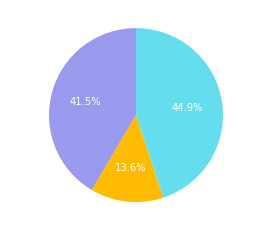

{'albums': 98, 'artists': 32, 'playlists': 106}

In [71]:
library = {}
with open('json/YourLibrary.json', 'r') as f:
  library = json.load(f)

playlists = []
with open('json/Playlist1.json', 'r') as file:
  playlists = json.load(file)["playlists"]

print('liked songs', len(library['tracks']))

library = {
  "albums": len(library['albums']),
  "artists": len(library['artists']),
  "playlists": len(playlists)
}

plt.pie(library.values(), 
        # labels=tas.index, 
        colors=['#99e', "#fb0", "#6de"], 
        startangle=90, counterclock=True,
        labels=library.keys(),
        # labeldistance=0.5,
        autopct='%1.1f%%', 
        textprops={'color': 'white'}
        )
show('library_pie')
plt.show()

library